In [14]:
from pathlib import Path

import pandas as pd
import plotly.express as px

root = Path.cwd()
data_dir = root / "data"
if not data_dir.exists():
    if (root.parent / "data").exists():
        root = root.parent
        data_dir = root / "data"
    else:
        raise FileNotFoundError("Could not find data")

In [15]:
players_path = data_dir / "players.csv"
players_df = pd.read_csv(players_path)

players_df.shape

(3637, 21)

In [16]:
players_df.head(10)

,goal_id,tournament_id,tournament_name,year,match_id,match_name,match_date,match_time,team_id,home_team,...,player_id,player_name,given_name,family_name,minute_label,minute_regulation,minute_stoppage,match_period,own_goal,penalty
0,G-0001,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-01,France vs Mexico,-14417.0,15:00,T-30,1,...,P-05470,Lucien Laurent,Lucien,Laurent,19',19,0,first half,0,0
1,G-0002,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-01,France vs Mexico,-14417.0,15:00,T-30,1,...,P-99087,Marcel Langiller,Marcel,Langiller,40',40,0,first half,0,0
2,G-0003,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-01,France vs Mexico,-14417.0,15:00,T-30,1,...,P-60620,André Maschinot,André,Maschinot,43',43,0,first half,0,0
3,G-0004,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-01,France vs Mexico,-14417.0,15:00,T-46,0,...,P-94135,Juan Carreño,Juan,Carreño,70',70,0,second half,0,0
4,G-0005,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-01,France vs Mexico,-14417.0,15:00,T-30,1,...,P-60620,André Maschinot,André,Maschinot,87',87,0,second half,0,0
5,G-0006,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-02,United States vs Belgium,-14417.0,15:00,T-83,1,...,P-65185,Bart McGhee,Bart,McGhee,23',23,0,first half,0,0
6,G-0007,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-02,United States vs Belgium,-14417.0,15:00,T-83,1,...,P-37361,Tom Florie,Tom,Florie,45',45,0,first half,0,0
7,G-0008,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-02,United States vs Belgium,-14417.0,15:00,T-83,1,...,P-71973,Bert Patenaude,Bert,Patenaude,69',69,0,second half,0,0
8,G-0009,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-03,Yugoslavia vs Brazil,-14416.0,12:45,T-87,1,...,P-43349,Aleksandar Tirnanić,Aleksandar,Tirnanić,21',21,0,first half,0,0
9,G-0010,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-03,Yugoslavia vs Brazil,-14416.0,12:45,T-87,1,...,P-43734,Ivan Bek,Ivan,Bek,30',30,0,first half,0,0


In [17]:
# Filter to FIFA Men's World Cup goals only
players_men = players_df[
    players_df["tournament_name"].str.contains("FIFA Men's World Cup", case=False, na=False)
].copy()

players_men.head(10)

,goal_id,tournament_id,tournament_name,year,match_id,match_name,match_date,match_time,team_id,home_team,...,player_id,player_name,given_name,family_name,minute_label,minute_regulation,minute_stoppage,match_period,own_goal,penalty
0,G-0001,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-01,France vs Mexico,-14417.0,15:00,T-30,1,...,P-05470,Lucien Laurent,Lucien,Laurent,19',19,0,first half,0,0
1,G-0002,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-01,France vs Mexico,-14417.0,15:00,T-30,1,...,P-99087,Marcel Langiller,Marcel,Langiller,40',40,0,first half,0,0
2,G-0003,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-01,France vs Mexico,-14417.0,15:00,T-30,1,...,P-60620,André Maschinot,André,Maschinot,43',43,0,first half,0,0
3,G-0004,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-01,France vs Mexico,-14417.0,15:00,T-46,0,...,P-94135,Juan Carreño,Juan,Carreño,70',70,0,second half,0,0
4,G-0005,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-01,France vs Mexico,-14417.0,15:00,T-30,1,...,P-60620,André Maschinot,André,Maschinot,87',87,0,second half,0,0
5,G-0006,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-02,United States vs Belgium,-14417.0,15:00,T-83,1,...,P-65185,Bart McGhee,Bart,McGhee,23',23,0,first half,0,0
6,G-0007,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-02,United States vs Belgium,-14417.0,15:00,T-83,1,...,P-37361,Tom Florie,Tom,Florie,45',45,0,first half,0,0
7,G-0008,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-02,United States vs Belgium,-14417.0,15:00,T-83,1,...,P-71973,Bert Patenaude,Bert,Patenaude,69',69,0,second half,0,0
8,G-0009,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-03,Yugoslavia vs Brazil,-14416.0,12:45,T-87,1,...,P-43349,Aleksandar Tirnanić,Aleksandar,Tirnanić,21',21,0,first half,0,0
9,G-0010,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-03,Yugoslavia vs Brazil,-14416.0,12:45,T-87,1,...,P-43734,Ivan Bek,Ivan,Bek,30',30,0,first half,0,0


In [18]:
# Average goals per match by year
avg_goals = (
    players_men.groupby("year", as_index=False)
    .agg(total_goals=("goal_id", "count"), matches=("match_id", "nunique"))
)
avg_goals["avg_goals_per_match"] = (avg_goals["total_goals"] / avg_goals["matches"]).round(2)

px.line(
    avg_goals,
    x="year",
    y="avg_goals_per_match",
    markers=True,
    title="Average Goals per Match (FIFA Men's World Cup)",
)

In [19]:
# Goals per tournament (bar chart)
goals_by_tournament = (
    players_men.groupby(["year", "tournament_name"], as_index=False)
    .agg(total_goals=("goal_id", "count"))
)

px.bar(
    goals_by_tournament,
    x="year",
    y="total_goals",
    title="Goals per Tournament (FIFA Men's World Cup)",
)

In [20]:
# Top scorers table
top_scorers = (
    players_men.groupby("player_name")
    .size()
    .reset_index(name="goals")
    .sort_values("goals", ascending=False)
    .head(20)
)

top_scorers

,player_name,goals
890,Miroslav Klose,16
1402,not applicable Ronaldo,15
417,Gerd Müller,14
761,Lionel Messi,13
690,Just Fontaine,13
742,Kylian Mbappé,12
1382,not applicable Pelé,12
1188,Sándor Kocsis,11
697,Jürgen Klinsmann,11
397,Gabriel Batistuta,10


In [21]:
players_df.isna().sum().sort_values(ascending=False)

goal_id              0
player_id            0
own_goal             0
match_period         0
minute_stoppage      0
minute_regulation    0
minute_label         0
family_name          0
given_name           0
player_name          0
away_team            0
tournament_id        0
home_team            0
team_id              0
match_time           0
match_date           0
match_name           0
match_id             0
year                 0
tournament_name      0
penalty              0
dtype: int64

In [22]:
# Goals per tournament/year
(
    players_df.groupby(["year", "tournament_name"], dropna=False)
    .size()
    .reset_index(name="goals")
    .sort_values(["year", "goals"], ascending=[True, False])
    
)

,year,tournament_name,goals
0,1930,1930 FIFA Men's World Cup,70
1,1934,1934 FIFA Men's World Cup,70
2,1938,1938 FIFA Men's World Cup,84
3,1950,1950 FIFA Men's World Cup,88
4,1954,1954 FIFA Men's World Cup,140
5,1958,1958 FIFA Men's World Cup,126
6,1962,1962 FIFA Men's World Cup,89
7,1966,1966 FIFA Men's World Cup,89
8,1970,1970 FIFA Men's World Cup,95
9,1974,1974 FIFA Men's World Cup,97


In [23]:
# Top scorers (excluding own goals)
(
    players_df.loc[players_df["own_goal"] == 0]
    .groupby(["player_id", "player_name"], dropna=False)
    .size()
    .reset_index(name="goals")
    .sort_values("goals", ascending=False)
    .head(20)
)

,player_id,player_name,goals
133,P-07458,not applicable Marta,17
480,P-27787,Miroslav Klose,16
1128,P-62722,not applicable Ronaldo,15
947,P-52478,Birgit Prinz,14
1295,P-72441,Gerd Müller,14
1584,P-89236,Abby Wambach,14
1392,P-77939,Just Fontaine,13
246,P-14758,Lionel Messi,13
1151,P-64077,Kylian Mbappé,12
703,P-38906,not applicable Pelé,12


In [24]:
# Minute distribution (regulation + stoppage)
players_df["minute_total"] = (
    players_df["minute_regulation"].fillna(0) + players_df["minute_stoppage"].fillna(0)
)

players_df["minute_total"].describe()

count    3637.000000
mean       51.288425
std        27.535997
min         1.000000
25%        27.000000
50%        52.000000
75%        75.000000
max       122.000000
Name: minute_total, dtype: float64

In [25]:
# Goal type counts
players_df[["own_goal", "penalty"]].value_counts().reset_index(name="count")

,own_goal,penalty,count
0,0,0,3266
1,0,1,292
2,1,0,79


Text(0.5, 0, 'Minute')

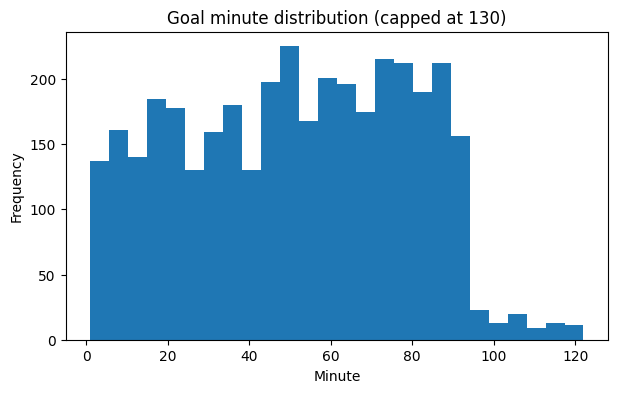

In [26]:
# Optional: quick histogram of goal minutes
ax = players_df["minute_total"].clip(lower=0, upper=130).plot.hist(
    bins=26, figsize=(7, 4), title="Goal minute distribution (capped at 130)"
)
ax.set_xlabel("Minute")

In [29]:
# Filter to FIFA Men's World Cup goals only
players_men = players_df[
    players_df["tournament_name"].str.contains("FIFA Men's World Cup", case=False, na=False)
].copy()

players_men.head(10)

,goal_id,tournament_id,tournament_name,year,match_id,match_name,match_date,match_time,team_id,home_team,...,player_name,given_name,family_name,minute_label,minute_regulation,minute_stoppage,match_period,own_goal,penalty,minute_total
0,G-0001,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-01,France vs Mexico,-14417.0,15:00,T-30,1,...,Lucien Laurent,Lucien,Laurent,19',19,0,first half,0,0,19
1,G-0002,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-01,France vs Mexico,-14417.0,15:00,T-30,1,...,Marcel Langiller,Marcel,Langiller,40',40,0,first half,0,0,40
2,G-0003,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-01,France vs Mexico,-14417.0,15:00,T-30,1,...,André Maschinot,André,Maschinot,43',43,0,first half,0,0,43
3,G-0004,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-01,France vs Mexico,-14417.0,15:00,T-46,0,...,Juan Carreño,Juan,Carreño,70',70,0,second half,0,0,70
4,G-0005,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-01,France vs Mexico,-14417.0,15:00,T-30,1,...,André Maschinot,André,Maschinot,87',87,0,second half,0,0,87
5,G-0006,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-02,United States vs Belgium,-14417.0,15:00,T-83,1,...,Bart McGhee,Bart,McGhee,23',23,0,first half,0,0,23
6,G-0007,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-02,United States vs Belgium,-14417.0,15:00,T-83,1,...,Tom Florie,Tom,Florie,45',45,0,first half,0,0,45
7,G-0008,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-02,United States vs Belgium,-14417.0,15:00,T-83,1,...,Bert Patenaude,Bert,Patenaude,69',69,0,second half,0,0,69
8,G-0009,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-03,Yugoslavia vs Brazil,-14416.0,12:45,T-87,1,...,Aleksandar Tirnanić,Aleksandar,Tirnanić,21',21,0,first half,0,0,21
9,G-0010,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-03,Yugoslavia vs Brazil,-14416.0,12:45,T-87,1,...,Ivan Bek,Ivan,Bek,30',30,0,first half,0,0,30


In [30]:
# Average goals per match by year
avg_goals = (
    players_men.groupby("year", as_index=False)
    .agg(total_goals=("goal_id", "count"), matches=("match_id", "nunique"))
)
avg_goals["avg_goals_per_match"] = (avg_goals["total_goals"] / avg_goals["matches"]).round(2)

px.line(
    avg_goals,
    x="year",
    y="avg_goals_per_match",
    markers=True,
    title="Average Goals per Match (FIFA Men's World Cup)",
)

In [31]:
# Goals per tournament (bar chart)
goals_by_tournament = (
    players_men.groupby(["year", "tournament_name"], as_index=False)
    .agg(total_goals=("goal_id", "count"))
)

px.bar(
    goals_by_tournament,
    x="year",
    y="total_goals",
    title="Goals per Tournament (FIFA Men's World Cup)",
)

In [32]:
# Top scorers table

top_scorers = (
    players_men.groupby("player_name")
    .size()
    .reset_index(name="goals")
    .sort_values("goals", ascending=False)
    .head(20)
)

top_scorers

,player_name,goals
890,Miroslav Klose,16
1402,not applicable Ronaldo,15
417,Gerd Müller,14
761,Lionel Messi,13
690,Just Fontaine,13
742,Kylian Mbappé,12
1382,not applicable Pelé,12
1188,Sándor Kocsis,11
697,Jürgen Klinsmann,11
397,Gabriel Batistuta,10
